# Figure 1: Maximum tolerable read noise for Bayer-SMLM

10,000 bootstrapped fits of a 1,000-photon ATTO 565 molecule centred on a 12×12 Bayer grid.  
The molecule position is sampled uniformly within ±1 pixel of centre so that all sub-pixel Bayer filter positions are covered.  
Read noise is swept logarithmically from 0.01 to 10 RMS e⁻ to identify where the amplitude-SNR gate begins to reject fits.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import types
import sys
from scipy.spatial.distance import cdist

sys.path.append('../..')
from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions
PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions
plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions
I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions
M_F = MaskFunctions.Mask_Functions()

from src.Multicolour_Simulation_Functions import FittingStrategy, SimulationConfig, CameraParameters

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260310_181027.log
/tmp/ipykernel_2229112/4092055864.py:20: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
# --- Camera calibration (median scalars from real Ximea calibration) ---
data_folder = '../../Camera_Calibrations/Ximea_Camera/'
gain     = IO.read_tiff(os.path.join(data_folder, 'gain.tif'))
offset   = IO.read_tiff(os.path.join(data_folder, 'offset.tif'))
rqe      = IO.read_tiff(os.path.join(data_folder, 'rqe.tif'))

gain_median   = float(np.median(gain))
offset_median = float(np.median(offset))
rqe_median    = float(np.median(rqe))

# --- Grid size ---
image_size = 12   # pixels (12×12 Bayer grid)
pixel_size = 69   # nm

# --- Bayer pixel QYs ---
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])   # shape (3, n_wavelengths)

masks = M_F.get_masks(size_x=image_size, size_y=image_size)

# --- Optical filters (same as Figure1_3camerapatterns) ---
notch_filter    = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
filters = [dichroic_mirror, notch_filter]

# --- Smoothing function ---
smoothing_function = types.SimpleNamespace()
smoothing_function.args              = {'sigma': 1.5}
smoothing_function.extent            = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg          = 'image'

print(f'gain={gain_median:.3f}, offset={offset_median:.3f}, rqe={rqe_median:.4f}')

gain=0.414, offset=32.346, rqe=1.0000


In [13]:
# --- Simulation parameters ---
dye          = 'ATTO 565'
n_photons    = 1000
n_bootstrap  = 10000
n_photon_space = np.array([n_photons], dtype=float)

# Read-noise sweep: 25 points log-spaced from 0.01 to 10 RMS e-
read_noise_space = np.logspace(np.log10(0.01), np.log10(10.0), 300)

save_folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/Figure1_MaxReadNoise'
os.makedirs(save_folder, exist_ok=True)
print(f'Saving to: {save_folder}')
print(f'Read-noise range: {read_noise_space[0]:.4f} – {read_noise_space[-1]:.2f} RMS e-')

Saving to: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/Figure1_MaxReadNoise
Read-noise range: 0.0100 – 10.00 RMS e-


In [14]:
# --- Run bootstrap for each read-noise level ---
for rn in read_noise_space:
    flag = f'readnoise_{rn:.6f}_'
    print(f'\nRead noise = {rn:.4f} RMS e-  (flag={flag})')

    camera_parameters_dict = {
        'gain':                np.full((image_size, image_size), gain_median),
        'offset':              np.full((image_size, image_size), offset_median),
        'variance':            np.full((image_size, image_size), rn ** 2),
        'readnoise':           np.full((image_size, image_size), rn),
        'rqe':                 np.full((image_size, image_size), rqe_median),
        'masks':               masks,
        'pixel_QYs':           pixel_QYs,
        'pixel_order':         ['B', 'G', 'R'],
        'pixel_order_indices': {'B': 0, 'G': 1, 'R': 2},
    }

    config = SimulationConfig(
        n_bootstrap=n_bootstrap,
        background_photons=5.0,
        background_colour=[1, 1, 1],
        NA=1.49,
        pixel_size=pixel_size,
        cpu_fraction=0.9,
        save_raw_results=True,
        subtractx0y0=False,
        saverawimages=False,
        use_stochastic_photons=True,
        verbose=False,
    )

    MSF.test_simulation_method(
        dye=dye,
        filters=filters,
        wavelength=wavelength,
        camera_parameters=camera_parameters_dict,
        save_folder=save_folder,
        n_photon_space=n_photon_space,
        smoothing_function=smoothing_function,
        strategy=FittingStrategy.STANDARD,
        starting_flag=flag,
        config=config,
        overwrite=True,
    )


Read noise = 0.0100 RMS e-  (flag=readnoise_0.010000_)
Overwrite=True: Deleting existing results file: readnoise_0.010000_LM_method_ATTO 565_rawresults.h5
Analysed photon flux 1/1    Time elapsed: 0.094 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.094 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard



Read noise = 0.0102 RMS e-  (flag=readnoise_0.010234_)
Analysed photon flux 1/1    Time elapsed: 0.096 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.096 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard



Read noise = 0.0105 RMS e-  (flag=readnoise_0.010473_)
Analysed photon flux 1/1    Time elapsed: 0.094 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.094 min


...

INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard



Read noise = 9.7716 RMS e-  (flag=readnoise_9.771620_)
Analysed photon flux 1/1    Time elapsed: 0.097 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.097 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard



Read noise = 10.0000 RMS e-  (flag=readnoise_10.000000_)
Overwrite=True: Deleting existing results file: readnoise_10.000000_LM_method_ATTO 565_rawresults.h5
Analysed photon flux 1/1    Time elapsed: 0.095 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.095 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


In [15]:
# --- Load results and compute metrics ---
dyestr = dye.replace('/', '-')

sigma_xy_arr      = np.full(len(read_noise_space), np.nan)
colour_std_arr    = np.full(len(read_noise_space), np.nan)
fit_yield_arr     = np.full(len(read_noise_space), np.nan)   # fraction of non-NaN fits

for i, rn in enumerate(read_noise_space):
    flag = f'readnoise_{rn:.6f}_'

    gt_path  = os.path.join(save_folder, f'{flag}LM_method_{dyestr}_fittesting_input_groundtruthpositions.csv')
    raw_path = os.path.join(save_folder, f'{flag}LM_method_{dyestr}_rawresults.h5')
    inp_path = os.path.join(save_folder, f'{flag}LM_method_{dyestr}_fittesting_input_parameters.csv')

    if not (os.path.exists(gt_path) and os.path.exists(raw_path)):
        print(f'  Missing files for rn={rn:.4f}, skipping')
        continue

    gt      = pd.read_csv(gt_path)
    results = pd.read_hdf(raw_path)
    inp     = pd.read_csv(inp_path).to_numpy()[0]

    # photon_level=0 because n_photon_space has one entry
    results = results[results['photon_level'] == 0]

    x0 = gt['x0'].to_numpy() / pixel_size   # ground truth in pixels
    y0 = gt['y0'].to_numpy() / pixel_size

    # Yield: fraction of fits that returned a result (not NaN)
    valid = ~(results['xc'].isna() | results['yc'].isna())
    fit_yield_arr[i] = valid.mean()

    # Spatial precision on valid fits, with sanity bounds
    filt = valid & (
        (results['xc'] > 0) & (results['xc'] < image_size) &
        (results['yc'] > 0) & (results['yc'] < image_size) &
        (results['s_x'] > 0) & (results['s_y'] > 0)
    )
    if filt.sum() > 10:
        err_x = results['xc'].to_numpy()[filt] - x0[filt]
        err_y = results['yc'].to_numpy()[filt] - y0[filt]
        sigma_xy_arr[i] = np.sqrt((np.nanstd(err_x)**2 + np.nanstd(err_y)**2) / 2) * pixel_size

    # Colour precision: std of distance from expected BGR fractions
    dye_BGR = inp[-3:]
    dye_BGR = dye_BGR / np.sum(dye_BGR)
    colour_loc = np.expand_dims(dye_BGR, 0)
    if filt.sum() > 10:
        colour = np.vstack([
            results['A_B'].to_numpy()[filt],
            results['A_G'].to_numpy()[filt],
            results['A_R'].to_numpy()[filt],
        ]).T
        colour_std_arr[i] = np.nanstd(cdist(colour, colour_loc))

print('Done loading results.')
print(f'  Fit yield range: {np.nanmin(fit_yield_arr):.3f} – {np.nanmax(fit_yield_arr):.3f}')
print(f'  sigma_xy range:  {np.nanmin(sigma_xy_arr):.2f} – {np.nanmax(sigma_xy_arr):.2f} nm')

Done loading results.
  Fit yield range: 0.566 – 0.984
  sigma_xy range:  6.84 – 53.89 nm


In [20]:
from scipy import interpolate
spl = interpolate.make_interp_spline(x=read_noise_space, y=fit_yield_arr)

/tmp/ipykernel_2229112/712658194.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


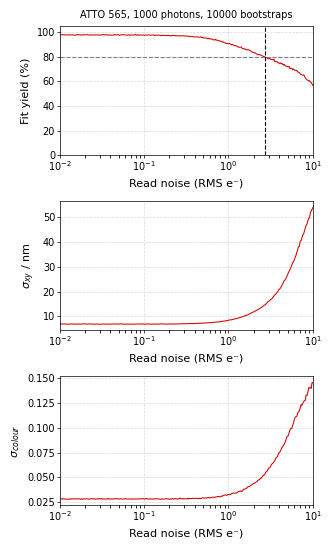

In [34]:
# --- Plot ---
fig, axs = plotter.one_column_plot(npanels=3, height=5.5, ratios=[1, 1, 1])

# Panel 0: fit yield
axs[0] = plotter.line_plot(
    axs[0], read_noise_space, fit_yield_arr * 100,
    xaxislabel='Read noise (RMS e⁻)',
    yaxislabel='Fit yield (%)',
    color='#d40000',
)
axs[0].set_xscale('log')
axs[0].set_ylim([0, 105])
axs[0].axhline(80, color='gray', ls='--', lw=0.8)
axs[0].set_title(f'ATTO 565, {n_photons} photons, {n_bootstrap} bootstraps', fontsize=7)
axs[0].axvline(2.7, ymin=0, ymax=110, ls='--', lw=0.8, color='black')
# Panel 1: localisation precision
axs[1] = plotter.line_plot(
    axs[1], read_noise_space, sigma_xy_arr,
    xaxislabel='Read noise (RMS e⁻)',
    yaxislabel=r'$\sigma_{xy}$ / nm',
    color='#d40000',
)
axs[1].set_xscale('log')

# Panel 2: colour precision
axs[2] = plotter.line_plot(
    axs[2], read_noise_space, colour_std_arr,
    xaxislabel='Read noise (RMS e⁻)',
    yaxislabel=r'$\sigma_{colour}$',
    color='#d40000',
)
axs[2].set_xscale('log')
for i in np.arange(3):
    axs[i].set_xlim([1e-2, 10])
plt.tight_layout()
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/Lowest_Noise_Level/'
plt.savefig(os.path.join(folder, 'Noise_Level_Experiment.svg'), dpi=600, format='svg')
plt.show()